# Stage 3 — object + mass + gripper → grasp points

**Goal:** given the object and the gripper Stage 2 chose, say where to put the fingers.

Two parts, deliberately separate:

1. **Propose** candidate grasps — done analytically from the object's shape. No learned generator.
2. **Score** them — a small model trained on 89,512 physics-labelled grasps.

Splitting it this way means the proposals are always geometrically valid (they respect the real
aperture and approach clearance), and the learned part only has to rank.

In [1]:
import json, pathlib, warnings
import numpy as np, pandas as pd, torch, torch.nn as nn, trimesh
import matplotlib.pyplot as plt
from scipy.spatial import cKDTree
from sklearn.metrics import roc_auc_score
from sklearn.model_selection import GroupShuffleSplit
warnings.filterwarnings("ignore")
RES = pathlib.Path.cwd()/"results"; REPO = pathlib.Path.cwd().parent
plt.rcParams.update({"font.size":9,"axes.spines.top":False,"axes.spines.right":False})
G = json.load(open(RES/"my_gripper_params.json"))
print("our gripper, measured from the STL files:")
for k,v in G["measured_mm"].items(): print(f"  {k:<14} {v} mm")
for n,g in G["grippers"].items():
    print(f"  {n:<10} open aperture {1000*g['extents_open'][0]:.0f} mm, "
          f"reach {1000*g['extents_open'][2]:.0f} mm, {g['n_contacts']} contacts")

our gripper, measured from the STL files:
  finger_len     85.0 mm
  finger_wide    30.0 mm
  finger_thick   10.0 mm
  body_width     50.6 mm
  body_height    60.1 mm
  2-finger   open aperture 148 mm, reach 38 mm, 2 contacts
  4-finger   open aperture 148 mm, reach 38 mm, 4 contacts


## 1. Propose grasps from shape

No learned generator. Antipodal pairs for the 2-finger, top-down envelopes for the 4-finger.

In [2]:
def propose(pts, aperture, n_contacts, n=200, seed=0):
    """Candidate grasp frames. z = approach direction, x = closing direction.

    2-finger: find a pair of opposing surface points closer together than the aperture and put the
    contact midway between them. 4-finger: centre on the object, approach along an axis it fits.
    """
    rng = np.random.default_rng(seed); out = []
    c = pts.mean(0)
    ev, R = np.linalg.eigh(np.cov((pts - c).T)); R = R[:, ev.argsort()[::-1]]
    long_ax, short_ax = R[:, 0], R[:, 2]

    def blocked(centre, app):
        v = pts - centre
        return (((v @ app) < -0.005) & (np.linalg.norm(v, axis=1) < aperture)).mean() > 0.25

    app = -short_ax if abs(short_ax[2]) > abs(long_ax[2]) else -long_ax
    if app[2] > 0: app = -app
    app = app / np.linalg.norm(app)

    for _ in range(n * 20):
        if len(out) >= n: break
        if n_contacts == 2:
            p = pts[rng.integers(len(pts))]
            close = R[:, rng.integers(0, 3)] * rng.choice([-1, 1])
            rel = pts - p
            proj = rel @ close
            perp = np.linalg.norm(rel - np.outer(proj, close), axis=1)
            cand = pts[(proj > 0.005) & (proj < aperture) & (perp < 0.015)]
            if len(cand) < 3: continue
            far = cand[np.argmax((cand - p) @ close)]
            if np.linalg.norm(far - p) > aperture: continue
            centre = (p + far) / 2
        else:
            if np.ptp((pts - c) @ short_ax) > aperture: continue
            centre = c + short_ax * rng.normal(0, 0.005)
            close = R[:, rng.integers(0, 3)]
        close = close - app * (close @ app)
        if np.linalg.norm(close) < 1e-6: continue
        close = close / np.linalg.norm(close)
        if blocked(centre, app): continue
        T = np.eye(4); T[:3,0]=close; T[:3,1]=np.cross(app,close); T[:3,2]=app; T[:3,3]=centre
        out.append(T)
    return np.array(out) if out else np.zeros((0, 4, 4))

# Load a real object AT ITS TRUE SIZE. Raw Objaverse meshes are in arbitrary units; the dataset
# stores the scale that makes them physical. Forgetting it gives a 9-metre bottle.
import pandas as pd
lab = pd.read_csv(REPO/"stage2_gripper/results/gripper_labels.csv").set_index("uuid")
mm = json.load(open(REPO/"data/graspgen/meshes/map_uuid_to_path.json"))
demo = [u for u in mm if u in lab.index][:6]

print(f"{'object':<22}{'size (mm)':>16}{'2-finger':>11}{'4-finger':>11}")
prop_stats = {}
for u in demo:
    m = trimesh.load(REPO/"data/graspgen"/mm[u], force="mesh")
    m.apply_scale(float(lab.loc[u, "scale"]))
    np.random.seed(0); p,_ = trimesh.sample.sample_surface(m, 2048)
    p = np.asarray(p, np.float32); p = p - p.mean(0)
    tree = cKDTree(p); row = []
    for name, g in G["grippers"].items():
        T = propose(p, g["extents_open"][0], g["n_contacts"])
        d = tree.query(T[:, :3, 3])[0] if len(T) else np.array([np.nan])
        row.append((len(T), 1000*np.nanmean(d)))
        prop_stats.setdefault(name, []).append((len(T), float(np.nanmean(d))))
    ext = np.round(1000*m.bounding_box.extents).astype(int)
    print(f"{lab.loc[u,'category'][:22]:<22}{str(ext):>16}"
          f"{row[0][0]:>6} ({row[0][1]:.0f}mm){row[1][0]:>5} ({row[1][1]:.0f}mm)")
print("\n(count of proposed grasps, and how far the contact point sits from the surface)")


object                       size (mm)   2-finger   4-finger


tag                      [157  60  91]   200 (5mm)  147 (9mm)


baseball_cap             [132  73 158]   200 (4mm)    0 (nanmm)


cloak                    [138  40 211]   200 (5mm)    0 (nanmm)


crown                    [145  57 144]   200 (4mm)    0 (nanmm)


prawn                    [108 102 233]   200 (4mm)    0 (nanmm)


rifle                    [ 17  60 329]   200 (2mm)    0 (nanmm)

(count of proposed grasps, and how far the contact point sits from the surface)


## 2. Train the scorer

89,512 grasps with physics outcomes. 18 geometric features describing each grasp, plus the object's mass.

In [3]:
d = np.load(RES/"grasp_features.npz", allow_pickle=True)
X, y, obj, grip, cat = d["X"].astype(np.float32), d["y"].astype(int), d["obj"], d["grip"], d["cat"]
print(f"{len(X)} grasps, {len(np.unique(obj))} objects, {y.mean():.1%} succeeded")

DENSITY={"metal":7800,"glass":2500,"wood":600,"plastic":950,"rubber":1200,"paper":800,"fabric":350,"foam":60}
def dens(c):
    c=c.lower()
    for k,v in DENSITY.items():
        if k in c: return v
    return 700.
mass_of = {o: dens(c) for o,c in zip(obj,cat)}
mass_feat = np.array([mass_of[o] for o in obj], np.float32)[:,None]

def train(Xtr,ytr,Xva,yva,seed=0,hidden=128,epochs=80):
    torch.manual_seed(seed)
    net=nn.Sequential(nn.Linear(Xtr.shape[1],hidden),nn.ReLU(),nn.Dropout(.2),
                      nn.Linear(hidden,64),nn.ReLU(),nn.Linear(64,1))
    opt=torch.optim.AdamW(net.parameters(),lr=2e-3,weight_decay=1e-4)
    Xtr,ytr=torch.tensor(Xtr),torch.tensor(ytr,dtype=torch.float32)[:,None]
    Xva,yva=torch.tensor(Xva),torch.tensor(yva,dtype=torch.float32)[:,None]
    best,st,bad=1e9,None,0
    for _ in range(epochs):
        net.train()
        for i in torch.randperm(len(Xtr)).split(512):
            opt.zero_grad(); nn.functional.binary_cross_entropy_with_logits(net(Xtr[i]),ytr[i]).backward(); opt.step()
        net.eval()
        with torch.no_grad(): v=float(nn.functional.binary_cross_entropy_with_logits(net(Xva),yva))
        if v<best-1e-4: best,st,bad=v,{k:t.clone() for k,t in net.state_dict().items()},0
        else:
            bad+=1
            if bad>=10: break
    net.load_state_dict(st); net.eval(); return net

89512 grasps, 226 objects, 54.4% succeeded


In [4]:
def per_object_auc(p,yy,oo):
    a=[]
    for o in np.unique(oo):
        m=oo==o
        if 0<yy[m].sum()<m.sum(): a.append(roc_auc_score(yy[m],p[m]))
    return float(np.mean(a)), len(a)

mu,sd = X.mean(0), X.std(0)+1e-8
tv,te = next(GroupShuffleSplit(1,test_size=.25,random_state=0).split(X,groups=obj))
a,b = next(GroupShuffleSplit(1,test_size=.15,random_state=1).split(tv,groups=obj[tv]))
tr,va = tv[a], tv[b]
gflag = (grip=="franka").astype(np.float32)[:,None]

res={}
for name, F in (("geometry only", np.hstack([(X-mu)/sd, gflag])),
                ("geometry + mass", np.hstack([(X-mu)/sd, gflag, np.log(mass_feat)/10]))):
    net = train(F[tr],y[tr],F[va],y[va])
    with torch.no_grad(): p = torch.sigmoid(net(torch.tensor(F[te]))).numpy().ravel()
    for g in ("franka","robotiq"):
        mk = grip[te]==g
        auc,n = per_object_auc(p[mk], y[te][mk], obj[te][mk])
        res[f"{name} | {g}"]=auc
        print(f"  {name:<18} {g:<9} per-object AUC {auc:.3f}  ({n} objects)")

  geometry only      franka    per-object AUC 0.607  (51 objects)
  geometry only      robotiq   per-object AUC 0.587  (57 objects)


  geometry + mass    franka    per-object AUC 0.613  (51 objects)
  geometry + mass    robotiq   per-object AUC 0.581  (57 objects)


## 3. Results

saved results/stage3.png, stage3_metrics.json


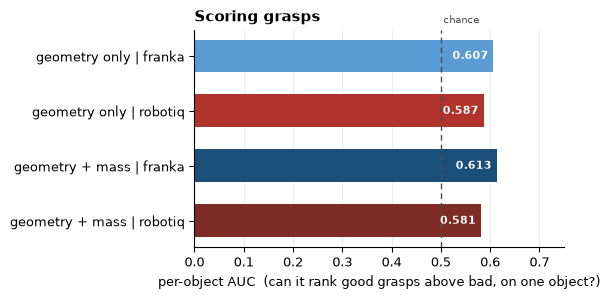

In [5]:
fig, ax = plt.subplots(figsize=(6.6,3.2)); fig.subplots_adjust(left=.34, bottom=.2)
k=list(res); v=[res[x] for x in k]
ax.barh(range(len(k)), v, color=["#5b9bd5","#b0342c","#1a4f7a","#7d2b24"], height=.6)
for i,x in enumerate(v): ax.text(x-.01,i,f"{x:.3f}",va="center",ha="right",color="white",fontweight="bold",fontsize=8)
ax.axvline(.5,color=".3",ls=(0,(4,3)),lw=1); ax.text(.505,-.6,"chance",fontsize=7.5,color=".3")
ax.set_yticks(range(len(k))); ax.set_yticklabels(k); ax.invert_yaxis()
ax.set_xlim(0,.75); ax.set_xlabel("per-object AUC  (can it rank good grasps above bad, on one object?)")
ax.set_title("Scoring grasps", loc="left", fontweight="bold")
ax.grid(axis="x",color=".93"); ax.set_axisbelow(True)
fig.savefig(RES/"stage3.png", dpi=200, bbox_inches="tight", facecolor="white")
json.dump({"scorer":res,"n_grasps":int(len(X)),"n_objects":int(len(np.unique(obj)))},
          open(RES/"stage3_metrics.json","w"), indent=1)
print("saved results/stage3.png, stage3_metrics.json")